In [ ]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS
from model import ADModel
from dataset import create_dataloaders
from data_split import create_train_val_split
from visualization import plot_training_curves

## Configuration Parameters


In [ ]:
DATASET_NAME = "ADReSS-M"

In [ ]:
TRAIN_PLOT_COLOR = '#2E86AB' 
VAL_PLOT_COLOR = '#A23B72'

In [ ]:
# ========== Path Configuration ==========
PROJECT_ROOT = script_dir.parent.parent.parent
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemap-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemap-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}_merged"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}_egemap_multi_seed"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EGEMAP_FEATURE_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_egemap_features"

# ========== Training Parameters ==========
MAX_EPOCHS = 50
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-2
NUM_WORKERS = 4
TRAIN_RATIO = 0.8
RANDOM_SEEDS = [21, 42, 84, 168, 336]
DATA_SPLIT_SEED = 42

## Step 1: Create Train/Val Split for Address Dataset


In [ ]:
# Use the create_train_val_split function with eGeMAPS mode
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir=RAW_AUDIO_DIR,
    train_csv_path=TRAIN_CSV,
    val_csv_path=VAL_CSV,
    feature_dir_name=EGEMAP_FEATURE_DIR,
    train_ratio=TRAIN_RATIO,
    random_seed=DATA_SPLIT_SEED,
    dataset_name=DATASET_NAME,
    xlsr=False  # eGeMAPS mode
)


## Step 2: Extract eGeMAPS Features

In [6]:
import sys
from pathlib import Path

# extract_features.py is now in the same directory; import directly
from extract_egemap_feature import extract_features_from_csv

print("=" * 60)
print("Starting to extract eGeMAPS features...")
print("=" * 60)
print()

# Extract features for the training set
if TRAIN_CSV.exists():
    print("======== Extracting training set features ========")
    print(f"CSV path: {TRAIN_CSV}")
    print(f"Audio directory: {RAW_AUDIO_DIR}")
    extract_features_from_csv(TRAIN_CSV, raw_audio_dir=RAW_AUDIO_DIR)
else:
    print(f"⚠️  Training CSV does not exist: {TRAIN_CSV}")
    print()

# Extract features for the validation set
if VAL_CSV.exists():
    print("======== Extracting validation set features ========")
    print(f"CSV path: {VAL_CSV}")
    print(f"Audio directory: {RAW_AUDIO_DIR}")
    extract_features_from_csv(VAL_CSV, raw_audio_dir=RAW_AUDIO_DIR)
else:
    print(f"⚠️  Validation CSV does not exist: {VAL_CSV}")
    print()

Extracting: 100%|██████████| 189/189 [04:02<00:00,  1.28s/it]



============= Extraction completed! =============
Successfully extracted: 152 个
Skipped: 37 个
Total: 189 个
======== Extracting validation set features ========
CSV path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/ADReSS-M-egemap-val.csv
Audio directory: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/raw/ADReSS-M_merged
48 Audio Files



Extracting: 100%|██████████| 48/48 [01:12<00:00,  1.51s/it]


============= Extraction completed! =============
Successfully extracted: 48 个
Skipped: 0 个
Total: 48 个


## Step 3: Create Data Loaders


In [7]:
train_loader, val_loader = create_dataloaders(
    TRAIN_CSV, VAL_CSV, PROJECT_ROOT, 
    BATCH_SIZE, NUM_WORKERS
)

all_results = {'seeds': [], 'val_accs': [], 'val_losses': []}

============= Creating training set (eGeMAPS features) =============
✅ Loading completed: 189 samples
   Control: 92, Dementia: 97

============= Creating validation set (eGeMAPS features) =============
✅ Loading completed: 48 samples
   Control: 23, Dementia: 25



## Step 4: Define Training Function and Model

In [8]:
class MetricsCallback(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = []
    
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get('train_loss', 0).item())
        self.train_acc.append(trainer.callback_metrics.get('train_acc', 0).item())
    
    def on_validation_end(self, trainer, pl_module):
        if not trainer.sanity_checking:
            self.epochs.append(trainer.current_epoch)
            self.val_loss.append(trainer.callback_metrics.get('val_loss', 0).item())
            self.val_acc.append(trainer.callback_metrics.get('val_acc', 0).item())

class ADClassifier(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = ADModel(DEFAULT_CONFIG)
        self.save_hyperparameters()
    def forward(self, x):
        return self.model(x)
    def training_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_and_plot(seed, output_dir):
    """Train single seed and visualize"""
    pl.seed_everything(seed)
    seed_dir = output_dir / f"seed_{seed}"
    seed_dir.mkdir(exist_ok=True)
    
    model = ADClassifier()
    metrics_cb = MetricsCallback()
    callbacks = [
        ModelCheckpoint(dirpath=seed_dir, filename='best', monitor='val_acc', mode='max', save_top_k=1),
        EarlyStopping(monitor='val_acc', patience=10, mode='max'),
        metrics_cb
    ]
    
    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
    trainer_kwargs = {'max_epochs': MAX_EPOCHS, 'callbacks': callbacks, 'accelerator': accelerator,
                     'enable_progress_bar': True, 'enable_model_summary': False}
    if accelerator == 'gpu':
        trainer_kwargs['devices'] = 1
    trainer = pl.Trainer(**trainer_kwargs)
    
    trainer.fit(model, train_loader, val_loader)
    
    # Plot training curves using the visualization module
    plot_training_curves(
        epochs=metrics_cb.epochs,
        train_loss=metrics_cb.train_loss,
        val_loss=metrics_cb.val_loss,
        train_acc=metrics_cb.train_acc,
        val_acc=metrics_cb.val_acc,
        train_color=TRAIN_PLOT_COLOR,
        val_color=VAL_PLOT_COLOR,
        title_prefix=f'Seed {seed}'
    )

    best_val_acc_val = max(metrics_cb.val_acc)
    best_val_loss = min(metrics_cb.val_loss)
    print(f" Seed {seed} : Val Acc = {best_val_acc_val*100:.2f}%, Val Loss = {best_val_loss:.4f}")
    
    return seed, best_val_acc_val, best_val_loss

### 1st Random Seed = 21

Seed set to 21
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 14: 100%|██████████| 6/6 [00:00<00:00, 196.19it/s, v_num=147, train_loss_step=0.665, train_acc_step=0.552, val_loss=0.681, val_acc=0.500, train_loss_epoch=0.671, train_acc_epoch=0.598]


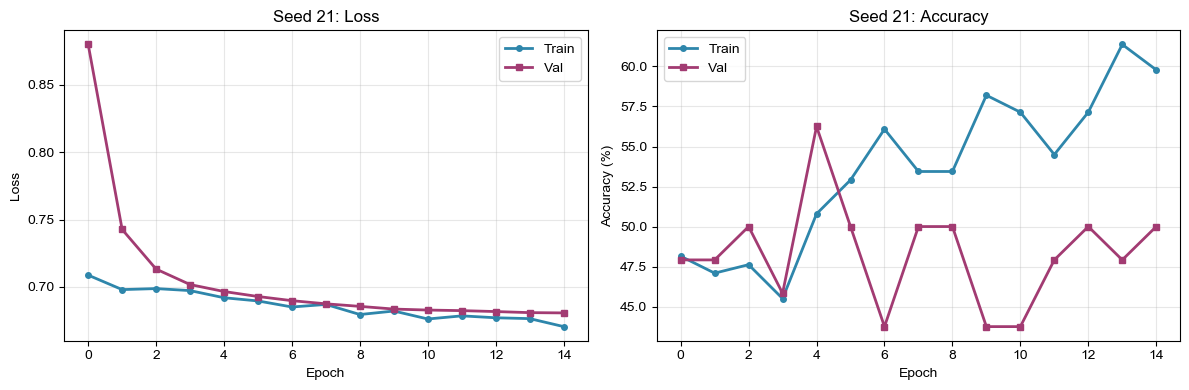

 Seed 21 : Val Acc = 56.25%, Val Loss = 0.6808


In [9]:
# Train Seed 21
seed, val_acc, val_loss = train_and_plot(21, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 2nd Random Seed = 42

Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 14: 100%|██████████| 6/6 [00:00<00:00, 232.46it/s, v_num=148, train_loss_step=0.686, train_acc_step=0.483, val_loss=0.682, val_acc=0.458, train_loss_epoch=0.676, train_acc_epoch=0.619]


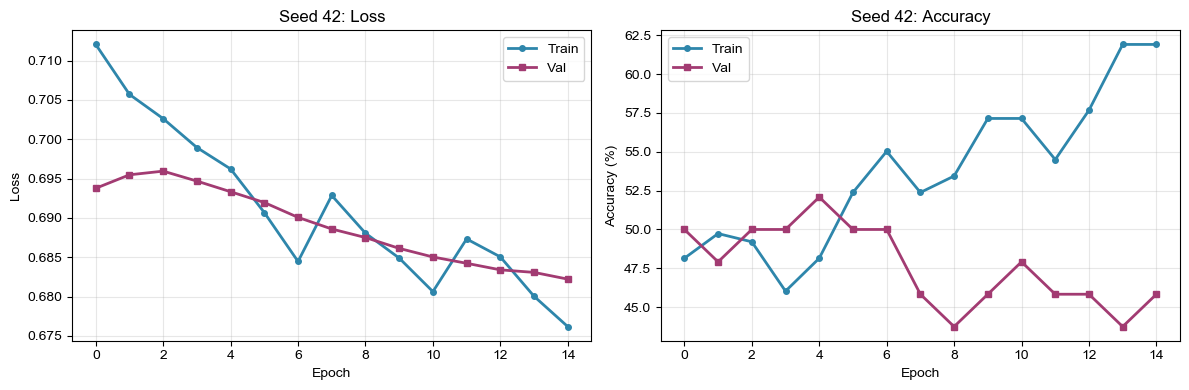

 Seed 42 : Val Acc = 52.08%, Val Loss = 0.6822


In [10]:
# Train Seed 42
seed, val_acc, val_loss = train_and_plot(42, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 3rd Random Seed = 84

Seed set to 84
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 10: 100%|██████████| 6/6 [00:00<00:00, 192.98it/s, v_num=149, train_loss_step=0.681, train_acc_step=0.586, val_loss=0.689, val_acc=0.417, train_loss_epoch=0.675, train_acc_epoch=0.598]


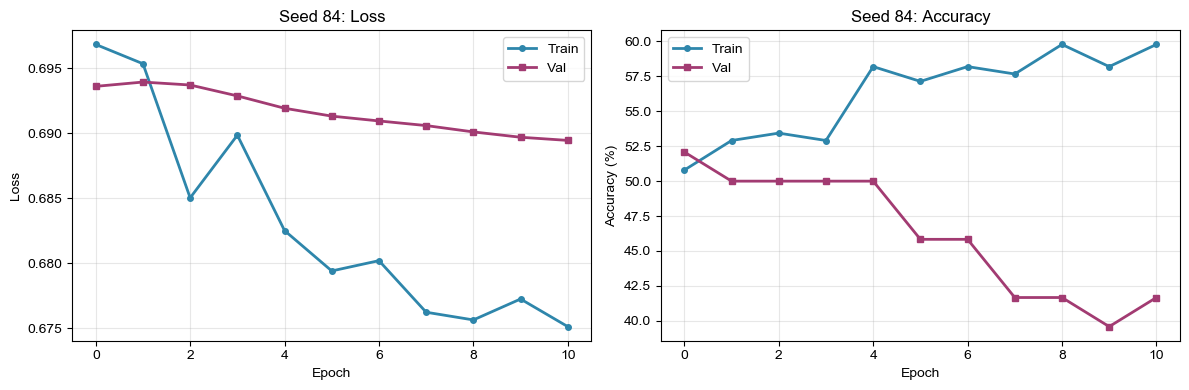

 Seed 84 : Val Acc = 52.08%, Val Loss = 0.6895


In [11]:
# Train Seed 84
seed, val_acc, val_loss = train_and_plot(84, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 4th Random Seed = 168

Seed set to 168
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 16: 100%|██████████| 6/6 [00:00<00:00, 196.83it/s, v_num=150, train_loss_step=0.689, train_acc_step=0.552, val_loss=0.686, val_acc=0.500, train_loss_epoch=0.679, train_acc_epoch=0.556]


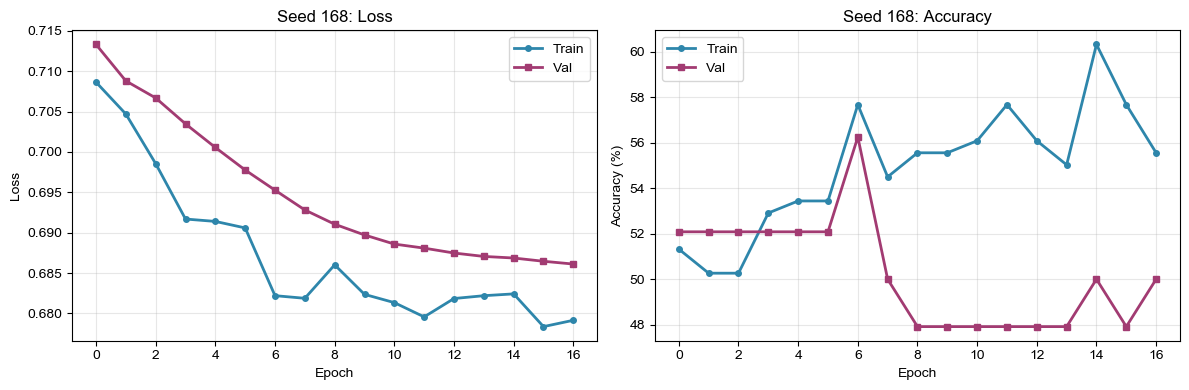

 Seed 168 : Val Acc = 56.25%, Val Loss = 0.6861


In [12]:
# Train Seed 168
seed, val_acc, val_loss = train_and_plot(168, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 5th Random Seed = 336

Seed set to 336
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 18: 100%|██████████| 6/6 [00:00<00:00, 206.97it/s, v_num=151, train_loss_step=0.682, train_acc_step=0.517, val_loss=0.676, val_acc=0.458, train_loss_epoch=0.670, train_acc_epoch=0.598]


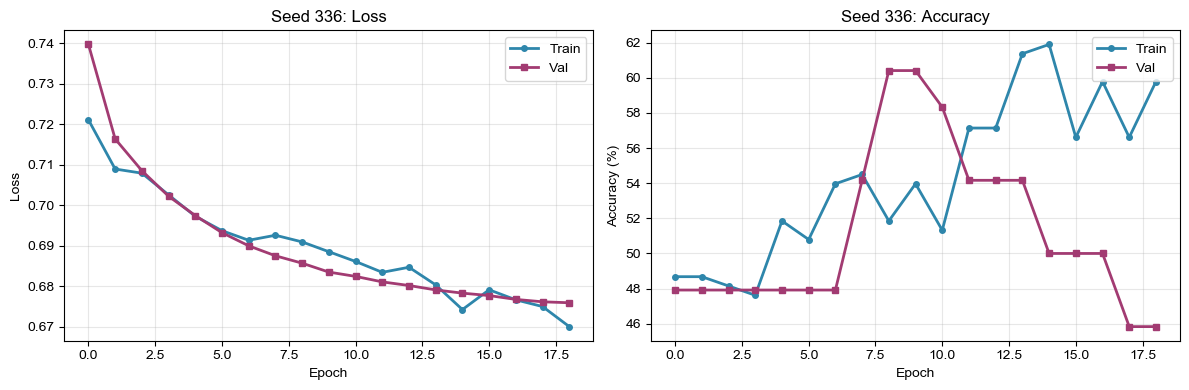

 Seed 336 : Val Acc = 60.42%, Val Loss = 0.6759


In [13]:
# Train Seed 336
seed, val_acc, val_loss = train_and_plot(336, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


In [14]:
# Compare all models
import numpy as np

seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']

# Calculate statistics
mean_acc = np.mean(val_accs)
mean_loss = np.mean(val_losses)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f}")
print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"  Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}")


Mean Validation Accuracy: 55.42%
Mean Validation Loss: 0.6829

Detailed Results:
  Seed 21: Acc=56.25%, Loss=0.6808
  Seed 42: Acc=52.08%, Loss=0.6822
  Seed 84: Acc=52.08%, Loss=0.6895
  Seed 168: Acc=56.25%, Loss=0.6861
  Seed 336: Acc=60.42%, Loss=0.6759
